### 이 프로젝트에서 모든 분석이 공통으로 사용하는
### delivered 기준, 고객 기준, 시간 기준이 적용된
### 단 하나의 기준 테이블을 만드는 노트북

[2-0] 데이터 로드 ✅
   ↓
[2-1] orders + payments 결합
   ↓
[2-2] 주문 단위 매출 계산
   ↓
[2-3] 월별 매출 / 주문 수 집계
   ↓
[2-4] 시각화 (주피터)

In [10]:
# [2-0] 라이브러리 불러오기 & 환경 설정
# - 분석에 필요한 기본 라이브러리 로드
# - 출력 옵션을 조정해 데이터 확인을 쉽게 함

import pandas as pd
import numpy as np

# pandas 출력 옵션 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [14]:
# [2-0-1] 데이터 파일 불러오기
# - raw CSV 파일을 pandas DataFrame으로 로드
# - 날짜 컬럼은 datetime 타입으로 변환 (이후 월/코호트 분석용)

base_path = "../data/raw/"

customers = pd.read_csv(base_path + "olist_customers_dataset.csv")

orders = pd.read_csv(
    base_path + "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date"
    ]
)

payments = pd.read_csv(base_path + "olist_order_payments_dataset.csv")

In [12]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [4]:
payments.shape

(103886, 5)

In [5]:
payments. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [13]:
payments.describe(include='all')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.00,103886,103886.00,103886.00
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.09,NaN,2.85,154.10
std,NaN,0.71,NaN,2.69,217.49
min,NaN,1.00,NaN,0.00,0.00
25%,NaN,1.00,NaN,1.00,56.79
50%,NaN,1.00,NaN,1.00,100.00
75%,NaN,1.00,NaN,4.00,171.84


#### 여기서 중요한 포인트 👇

•	payment_value <br>
•	평균: 약 154 <br>
•	최대값: 13,664 → 🚨 이상치 존재 <br>
•	payment_type <br>
•	대부분 credit_card <br>
•	payment_sequential <br>
•	최대 29 → 한 주문에 여러 결제 존재 가능 👉 이건 나중에 LTV 계산할 때 order 단위 집계 필요 <br>

### 첫 슬라이드에 들어가는 차트 만들기 : 매출은 괜찮아 보인다로 착시
#### 월별 총 매출
#### 월별 주문 수
#### (선택) 월별 고객수 / ARPU 

In [16]:
# [2-1] delivered 주문만 필터링
# - 분석 기준: 실제 고객에게 배송 완료된 주문만 사용

orders_delivered = orders[orders["order_status"] == "delivered"].copy() # 필터링된 데이터 복사

# 기본 확인 (boolean indexing)
print("전체 주문 수:", len(orders))
print("배송 완료 주문 수:", len(orders_delivered))

전체 주문 수: 99441
배송 완료 주문 수: 96478


In [18]:
# [2-2] order 단위 결제 금액 집계
# 하나의 주문에 여러 결제 row가 있을 수 있음

#groupby : 같은 order_id 묶기
#sum() : 주문별 총 결제금액
#as_index=False : DataFrame 유지

payment_by_order = (
    payments
    .groupby("order_id", as_index=False)["payment_value"]
    .sum()
)

payment_by_order.head()

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [19]:
# [2-3] order와 + payments 데이터 병합 
# 기준: delivered 주문 + 결제 금액 병합

orders_revenue = orders_delivered.merge(
    payment_by_order,
    on="order_id",
    how="inner"
)

orders_revenue.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,28.62


In [20]:
orders_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96477 entries, 0 to 96476
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96477 non-null  object        
 1   customer_id                    96477 non-null  object        
 2   order_status                   96477 non-null  object        
 3   order_purchase_timestamp       96477 non-null  datetime64[ns]
 4   order_approved_at              96463 non-null  object        
 5   order_delivered_carrier_date   96475 non-null  object        
 6   order_delivered_customer_date  96469 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96477 non-null  object        
 8   payment_value                  96477 non-null  float64       
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 6.6+ MB


##### 병합 후 결측치 컬럼 확인  (order_approved_at,order_delivered_carrier_date)하였으나, 일단 지금은 전처리 패스
#### dtype도 시간컬럼은 이미 datetime 형태, 매출은 float, 다른 문자열 문제 없음 확인
####  “배송 완료 기준 주문 단위 매출 테이블이 정상적으로 생성되었고, 월별 매출/주문 수 분석을 바로 진행할 수 있는 상태다.”  
---
## 매출이 괜찮아보인다는 것을 보여주는 차트만들기

In [24]:
# [2-4] 월별 매출 / 주문 수 집계
# - 슬라이드: "매출은 괜찮아 보인다"용 핵심 데이터

#	to_period("M") : 날짜 → 월 단위 변환
orders_revenue["order_month"] = (
    orders_revenue["order_purchase_timestamp"]
    .dt.to_period("M")
)


#agg: 여러 지표 한 번에 집계

monthly_summary = (
    orders_revenue
    .groupby("order_month")
    .agg(
        total_revenue=("payment_value", "sum"),
        order_count=("order_id", "nunique"),
        customer_count=("customer_id", "nunique")  # 선택
    )
    .reset_index()
)

monthly_summary.head(50)

,order_month,total_revenue,order_count,customer_count
0,2016-10,46566.71,265,265
1,2016-12,19.62,1,1
2,2017-01,127545.67,750,750
3,2017-02,271298.65,1653,1653
4,2017-03,414369.39,2546,2546
5,2017-04,390952.18,2303,2303
6,2017-05,567066.73,3546,3546
7,2017-06,490225.60,3135,3135
8,2017-07,566403.93,3872,3872
9,2017-08,646000.61,4193,4193


## [2-5] 월별 매출 추이 시각화 (가장 중요)


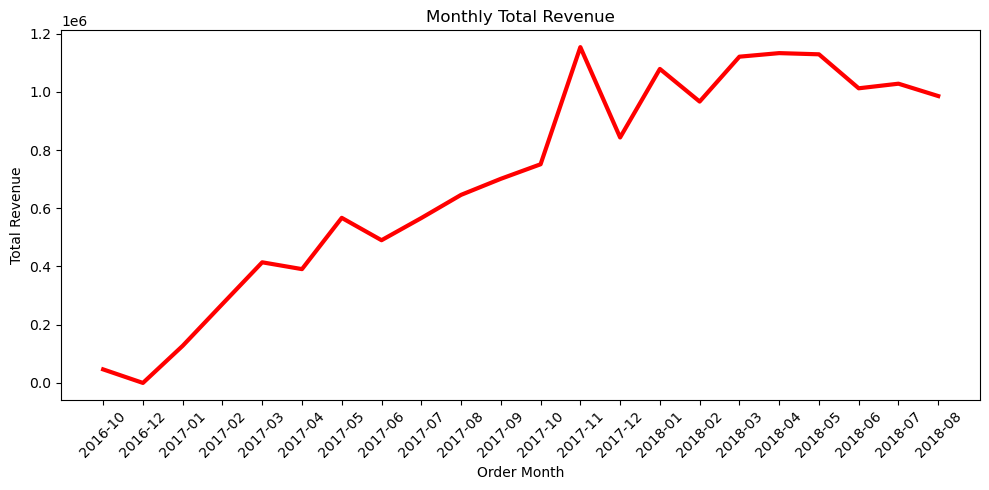

In [27]:
# [2-1-A] 월별 매출 추이 (발표용: 매출만)

import matplotlib.pyplot as plt

# x축: 월 (문자열로 변환 → 보기 좋게)
x = monthly_summary["order_month"].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(
    x,
    monthly_summary["total_revenue"],
    color="red",
    linewidth=3
)
plt.title("Monthly Total Revenue")
plt.xlabel("Order Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📌 요약
- Olist의 월별 총 매출은 전반적으로 증가 추세를 보인다.
- 단일 매출 지표만 보면 서비스는 안정적으로 성장하는 것처럼 보인다.

In [28]:
# [2-1-7] orders_revenue에 customer_unique_id 붙이기
# - customer_id는 주문 단위
# - customer_unique_id가 '진짜 고객' 단위

orders_revenue = orders_revenue.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

In [29]:
# [2-1-8] 월별 매출 / 주문 수 / 고객 수 (unique 기준)
monthly_summary_unique = (
    orders_revenue
    .groupby("order_month")
    .agg(
        total_revenue=("payment_value", "sum"),
        order_count=("order_id", "nunique"),
        customer_count=("customer_unique_id", "nunique")
    )
    .reset_index()
)

In [30]:
# [2-1-8.5-1] customer_unique_id 매핑 누락 확인
# - merge 후 customer_unique_id가 NaN이면 customers 매핑이 안 된 주문이 있다는 뜻

orders_revenue["customer_unique_id"].isna().mean()

np.float64(0.0)

In [31]:
# [2-1-8.5-2] 월별 집계표 5줄 확인
monthly_summary_unique.head()

,order_month,total_revenue,order_count,customer_count
0,2016-10,46566.71,265,262
1,2016-12,19.62,1,1
2,2017-01,127545.67,750,718
3,2017-02,271298.65,1653,1630
4,2017-03,414369.39,2546,2508


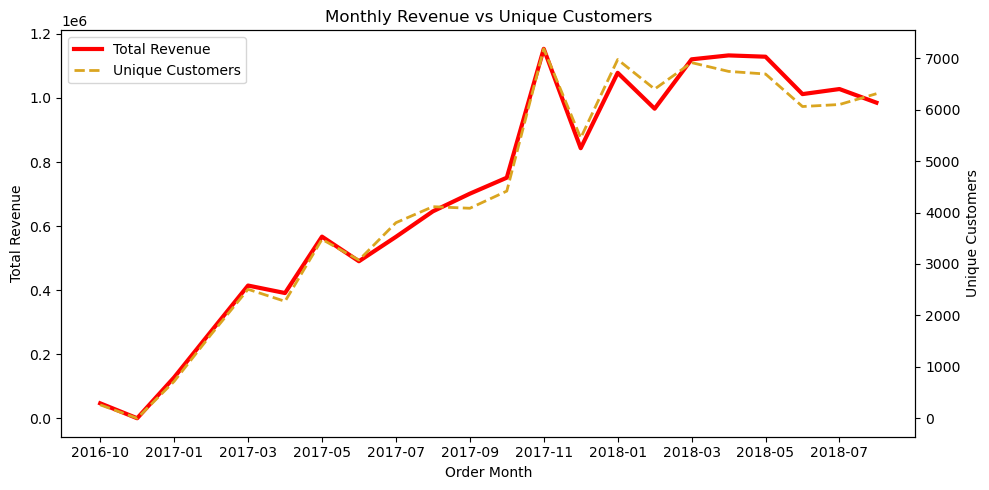

In [32]:
# [2-1-C-Fix2] x축 라벨 간격 줄이기 (2개월마다 표시)

import numpy as np

x = monthly_summary_unique["order_month"].astype(str)

fig, ax1 = plt.subplots(figsize=(10, 5))

# 매출
line1 = ax1.plot(
    x,
    monthly_summary_unique["total_revenue"],
    color="red",
    linewidth=3,
    label="Total Revenue"
)

ax2 = ax1.twinx()
line2 = ax2.plot(
    x,
    monthly_summary_unique["customer_count"],
    color="goldenrod",
    linestyle="--",
    linewidth=2,
    label="Unique Customers"
)

plt.title("Monthly Revenue vs Unique Customers")
ax1.set_xlabel("Order Month")
ax1.set_ylabel("Total Revenue")
ax2.set_ylabel("Unique Customers")

# ✅ 여기 핵심: x축 라벨 간격 조절
tick_idx = np.arange(0, len(x), 2)   # 2개월 간격
ax1.set_xticks(tick_idx)
ax1.set_xticklabels(x.iloc[tick_idx], rotation=0)

# 범례
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

fig.tight_layout()
plt.show()

### 월별 매출 & 고객 수 추이 요약

- Olist의 월별 매출은 전반적으로 증가하는 추세를 보인다.
- 월별 Unique Customer 수 또한 매출과 거의 동일한 패턴으로 증가한다.
- 매출과 고객 수가 함께 성장하는 구조로 보이며,
  이 지표만 보면 서비스는 안정적으로 성장하고 있는 것처럼 보인다.

👉 그러나 이는 ‘고객 단위’가 아닌 ‘집계 지표’ 기준의 관찰이다.
👉 다음 단계에서는 고객 단위로 분석 관점을 전환한다.

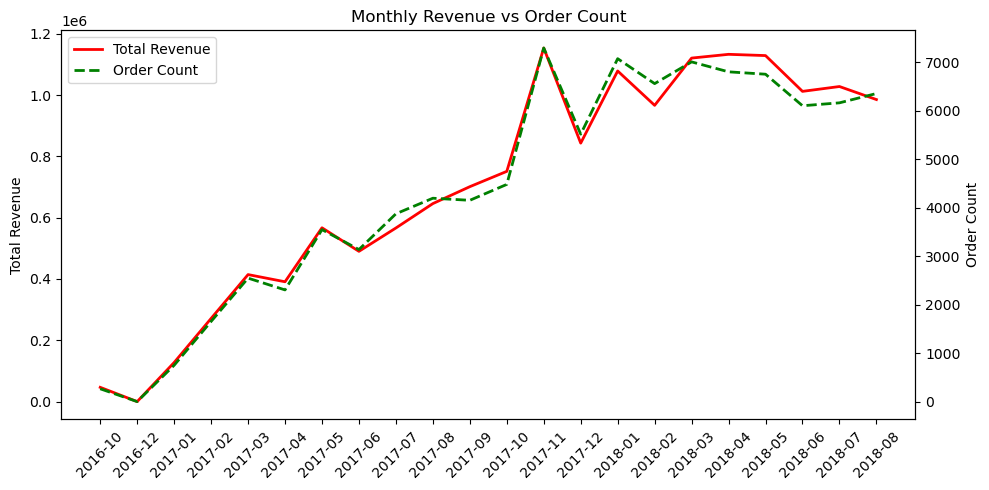

In [33]:
# [2-1-10] 월별 매출 vs 주문 수 시각화
# - 매출: 빨간색 실선
# - 주문 수: 초록색 점선
# → 거래가 꾸준히 늘어나는 것처럼 보이게 만드는 착시용 차트

x = monthly_summary["order_month"].astype(str)

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

# 매출 (왼쪽 축)
ax1.plot(
    x,
    monthly_summary["total_revenue"],
    color="red",
    linewidth=2,
    label="Total Revenue"
)
ax1.set_ylabel("Total Revenue")
ax1.tick_params(axis="x", rotation=45)

# 주문 수 (오른쪽 축)
ax2 = ax1.twinx()
ax2.plot(
    x,
    monthly_summary["order_count"],
    color="green",
    linestyle="--",
    linewidth=2,
    label="Order Count"
)
ax2.set_ylabel("Order Count")

plt.title("Monthly Revenue vs Order Count")

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

#### ARPU (Average Revenue Per User)= 특정 기간 동안 고객 1명당 평균 매출   
#### ARPU = 총 매출 / 구매 고객 수 (구매한 고객 기준)
#### 여기서 구매 고객의 정의도 분석에서의 활성유저 기준으로 적용함 ()

In [36]:
# [2-1-10] 월별 ARPU 계산
# - ARPU = 월 매출 / 월별 구매 고객 수
# - 고객 1명이 평균적으로 얼마를 쓰는지 보여주는 지표

monthly_summary_unique["arpu"] = (
    monthly_summary_unique["total_revenue"] 
    / monthly_summary_unique["customer_count"]
)

monthly_summary_unique.head()

,order_month,total_revenue,order_count,customer_count,arpu
0,2016-10,46566.71,265,262,177.74
1,2016-12,19.62,1,1,19.62
2,2017-01,127545.67,750,718,177.64
3,2017-02,271298.65,1653,1630,166.44
4,2017-03,414369.39,2546,2508,165.22


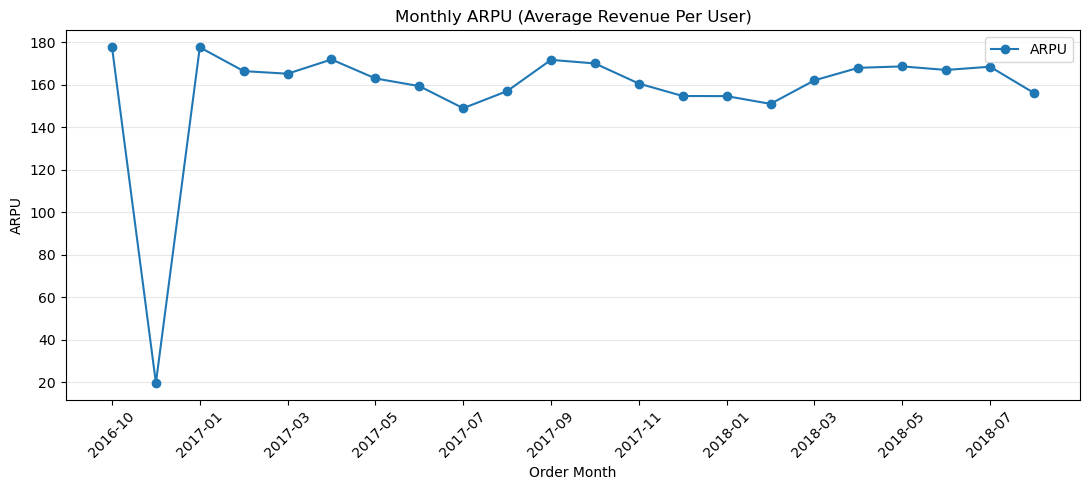

In [41]:
# [2-1-10] ARPU 시각화 (발표용: x축 간격 조정 + 표본수 표시)

x = monthly_summary_unique["order_month"].astype(str)
y = monthly_summary_unique["arpu"]
n = monthly_summary_unique["customer_count"]  # 월별 고객 수 (표본 수)

import matplotlib.pyplot as plt

plt.figure(figsize=(11, 5))

plt.plot(
    x, y,
    marker="o",
    linestyle="-",
    label="ARPU"
)

plt.title("Monthly ARPU (Average Revenue Per User)")
plt.xlabel("Order Month")
plt.ylabel("ARPU")

# ✔ x축 간격 조정 (2개월 단위)
plt.xticks(ticks=range(0, len(x), 2), labels=x[::2], rotation=45)

plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

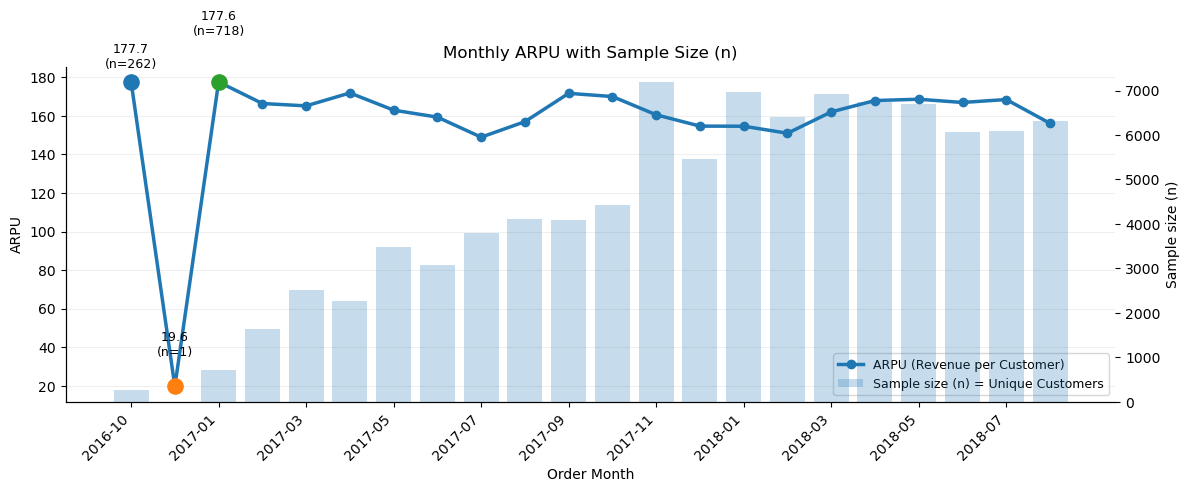

In [44]:
# [2-1-10] ARPU(고객당 매출) + 표본수(n) 동시 시각화
# - ARPU = total_revenue / customer_count
# - 표본수(n) = 그 달의 "구매 고객 수"(customer_unique_id unique)
# - 발표용: x축 겹침 방지, 3포인트 강조(첫 달 / 최저점 / 반등)

import matplotlib.pyplot as plt

df = monthly_summary_unique.copy()

# 1) ARPU 계산 (pandas: 새 컬럼 만들기)
df["arpu"] = df["total_revenue"] / df["customer_count"]

# 2) x축 라벨(월) 문자열로 변환 (matplotlib 축 표시용)
x = df["order_month"].astype(str)

# 3) 강조할 3개 포인트 선택
# - 첫 달
idx_first = df.index[0]

# - ARPU가 가장 낮은 달(=확 줄어든 달)
idx_min = df["arpu"].idxmin()

# - 다시 상승한 달: "최저점 바로 다음 달"을 기본으로 잡음(데이터 있으면)
#   (만약 최저점이 마지막 달이면, 그 이전 달로 fallback)
min_pos = df.index.get_loc(idx_min)
if min_pos < len(df) - 1:
    idx_rebound = df.index[min_pos + 1]
else:
    idx_rebound = df.index[min_pos - 1]

# 4) 그림 그리기 (이중축)
fig, ax1 = plt.subplots(figsize=(12, 5))

# (A) 표본수 n = 막대(bar), 오른쪽 축
ax2 = ax1.twinx()
ax2.bar(
    x,
    df["customer_count"],
    alpha=0.25,           # 막대는 연하게(선이 주인공)
    label="Sample size (n) = Unique Customers"
)
ax2.set_ylabel("Sample size (n)")

# (B) ARPU = 선(line), 왼쪽 축
ax1.plot(
    x,
    df["arpu"],
    linewidth=2.5,
    marker="o",
    label="ARPU (Revenue per Customer)"
)
ax1.set_ylabel("ARPU")
ax1.set_title("Monthly ARPU with Sample Size (n)")

# 5) x축 겹침 방지: 2칸(또는 3칸) 간격으로 표시
step = 2  # 더 줄이고 싶으면 3으로
ax1.set_xticks(range(0, len(x), step))
ax1.set_xticklabels(x[::step], rotation=45, ha="right")
ax1.set_xlabel("Order Month")


# 6) 3포인트 강조 라벨(글자 줄이고 겹침 방지)
def fmt_n(n):
    return f"{n/1000:.1f}k" if n >= 1000 else f"{n}"

highlight_idxs = [idx_first, idx_min, idx_rebound]
highlight_idxs = list(dict.fromkeys(highlight_idxs))  # ✅ 중복 제거

offsets = [(0, 10), (0, 22), (0, 34)]  # ✅ 서로 안 겹치게

for i, idx in enumerate(highlight_idxs):
    xm = str(df.loc[idx, "order_month"])
    y_arpu = df.loc[idx, "arpu"]
    n = int(df.loc[idx, "customer_count"])

    ax1.scatter(xm, y_arpu, s=120, zorder=5)

    ax1.annotate(
        f"{y_arpu:.1f}\n(n={fmt_n(n)})",    # ✅ 라벨 축약
        (xm, y_arpu),
        textcoords="offset points",
        xytext=offsets[min(i, len(offsets)-1)],
        ha="center",
        fontsize=9                           # ✅ 글자 줄이기
    )

# ✅ 박스 윗선 제거
for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ✅ 범례: 그래프 박스 안 오른쪽 하단
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="lower right",
    frameon=True,
    fontsize=9
)

ax1.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


1️⃣ ARPU 자체는 안정적이다
	•	대부분의 기간에서 ARPU는 약 150~170 수준으로 유지됨
	•	급격한 하락이나 붕괴는 보이지 않음
→ “고객 한 명당 쓰는 돈은 괜찮아 보인다”

2️⃣ 초기 2개월의 급격한 변동은 표본수 문제
	•	2016-10, 2016-12는 표본수(n)가 극히 작음
	•	평균(ARPU)이 왜곡될 수 있는 구간
→ 이후 분석에서는 초기 구간을 제외하는 것이 합리적

3️⃣ 표본수가 커진 이후에도 ARPU는 크게 변하지 않는다
	•	고객 수가 수천 명 단위로 증가한 이후에도
	•	ARPU는 여전히 비슷한 수준 유지
→ “유입 고객의 질이 급격히 나빠진 것 같지는 않다”

---
🔍 Step 2-2. 매출 착시 해소: 고객 구매 구조 점검

앞선 분석에서 Olist는  
- 월별 매출이 증가하고  
- 주문 수와 고객 수가 함께 늘어나며  
- 고객 1인당 평균 매출(ARPU)도 비교적 안정적인  
**‘겉보기에는 건강해 보이는 서비스’**처럼 보였다.

그러나 이 지표들은 모두 **총합(aggregate) 기준의 지표**로,  
고객이 **얼마나 자주 돌아오는지**에 대한 정보는 직접적으로 보여주지 않는다.

따라서 다음 단계에서는  
> **“이 매출은 얼마나 많은 ‘반복 고객’에 의해 만들어졌는가?”**  
를 확인하기 위해,

고객 단위(customer_unique_id) 기준으로  
**구매 횟수 분포를 분석**한다.

이 분석을 통해  
- 대부분의 고객이 실제로는 한 번만 구매하고 떠나는지,
- 소수의 반복 고객이 매출을 떠받치고 있는 구조인지  
를 명확히 확인한다.

## [2-2] 매출 착시 해소: 고객별 구매 횟수 구조 확인

In [45]:
# [2-2-1] 고객별 구매 횟수 계산
# 목적:
# - customer_unique_id 기준으로
# - 한 고객이 delivered 주문을 몇 번 했는지 계산
# - "재구매 고객이 얼마나 되는가?"의 기초 테이블

# pandas 개념:
# - groupby(): 기준 컬럼으로 묶기
# - nunique(): 중복 제거 후 개수 세기 (주문 id 중복 방지)

customer_order_counts = (
    orders_revenue
    .groupby("customer_unique_id")
    .agg(order_count=("order_id", "nunique"))
    .reset_index()
)

customer_order_counts.head()

,customer_unique_id,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [47]:
# [2-2-2] 고객별 구매 횟수 분포 (수치 확인)
# 목적:
# - 시각화 전에 숫자로 구조 감 잡기
# - 대부분이 1회 구매인지 확인

purchase_dist = (
    customer_order_counts["order_count"]
    .value_counts()
    .sort_index()
)

purchase_dist

order_count
1     90556
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [48]:
# [2-2-3] 1회 구매 고객 vs 재구매 고객 비율 계산
# 목적:
# - 발표에 쓸 핵심 숫자 만들기

total_customers = customer_order_counts.shape[0]

one_time_customers = (customer_order_counts["order_count"] == 1).sum()
repeat_customers = (customer_order_counts["order_count"] >= 2).sum()

one_time_ratio = one_time_customers / total_customers * 100
repeat_ratio = repeat_customers / total_customers * 100

total_customers, one_time_ratio, repeat_ratio

(93357, np.float64(96.99968936448258), np.float64(3.0003106355174225))

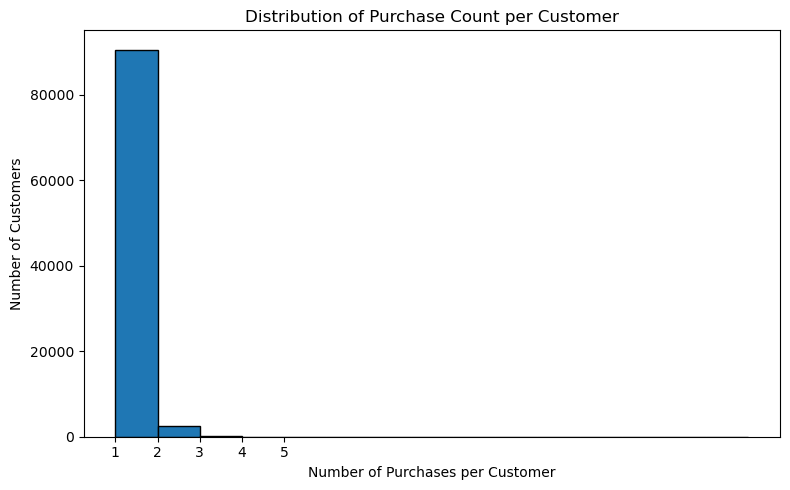

In [49]:
# [2-2-4] 고객별 구매 횟수 분포 시각화
# 목적:
# - "대부분 한 번만 사고 떠난다"를 직관적으로 보여주기

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    customer_order_counts["order_count"],
    bins=range(1, customer_order_counts["order_count"].max() + 2),
    edgecolor="black"
)

plt.title("Distribution of Purchase Count per Customer")
plt.xlabel("Number of Purchases per Customer")
plt.ylabel("Number of Customers")

plt.xticks(range(1, 6))  # 1~5까지만 보이게 (꼬리 제거)
plt.tight_layout()
plt.show()

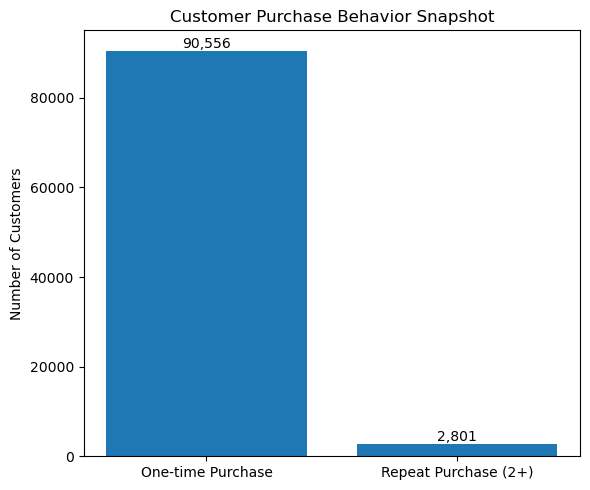

In [50]:
# [2-2-5] 1회 구매 vs 재구매 고객 수 비교
# 목적:
# - "97% vs 3%"를 한 방에 보여주는 차트

labels = ["One-time Purchase", "Repeat Purchase (2+)"]
values = [one_time_customers, repeat_customers]

plt.figure(figsize=(6, 5))

plt.bar(labels, values)

plt.title("Customer Purchase Behavior Snapshot")
plt.ylabel("Number of Customers")

for i, v in enumerate(values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

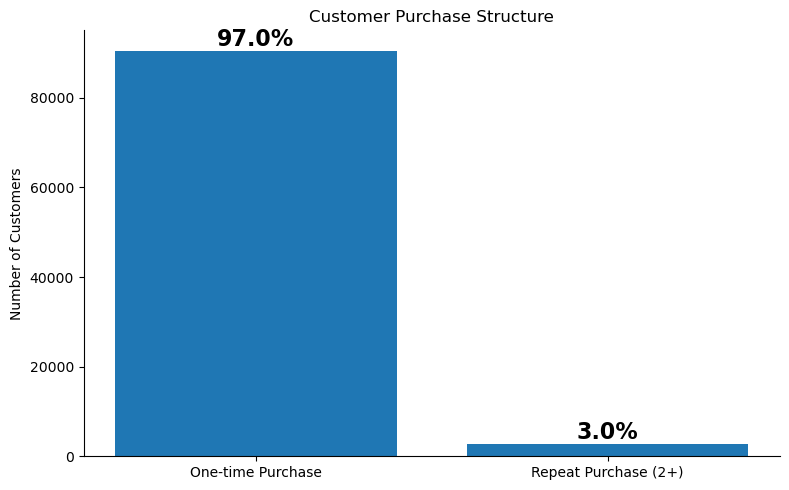

In [55]:
import matplotlib.pyplot as plt

total_customers = customer_order_counts.shape[0]
one_time_customers = (customer_order_counts["order_count"] == 1).sum()
repeat_customers = (customer_order_counts["order_count"] >= 2).sum()

labels = ["One-time Purchase", "Repeat Purchase (2+)"]
counts = [one_time_customers, repeat_customers]
percentages = [c / total_customers * 100 for c in counts]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts)

plt.ylabel("Number of Customers")
plt.title("Customer Purchase Structure")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### 필수 컬럼을 포함한 테이블(orders_base_delivered.csv)을 따로 저장해두기

In [56]:
#order_id
#customer_unique_id
#order_purchase_timestamp
#order_delivered_customer_date
#payment_value        (order 단위 합산된 매출)
#order_month          (Period[M] or string)

In [57]:
orders_revenue.to_csv(
    "../data/processed/orders_base_delivered.csv",
    index=False
)

#### 월별 집계 테이블 (monthly_metrics.csv)  

In [ ]:
#order_month
#total_revenue
#order_count
#customer_count
#arpu

In [58]:
monthly_summary_unique.to_csv(
    "../data/processed/monthly_metrics.csv",
    index=False
)

In [64]:
# 기준 테이블 재확인
orders_revenue.to_csv(
    "../data/processed/orders_base_delivered.csv",
    index=False
)
orders_revenue.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,order_month,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71,2017-10,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46,2018-07,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12,2018-08,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,72.20,2017-11,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,28.62,2018-02,72632f0f9dd73dfee390c9b22eb56dd6


In [65]:
print(orders_revenue.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_value', 'order_month', 'customer_unique_id'],
      dtype='object')


In [66]:
orders_base_delivered = orders_revenue[
    [
        "order_id",
        "customer_unique_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "payment_value",
        "order_month",
    ]
].copy()

orders_base_delivered.columns

Index(['order_id', 'customer_unique_id', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'payment_value', 'order_month'],
      dtype='object')

In [67]:
orders_base_delivered.to_csv(
    "../data/processed/orders_base_delivered.csv",
    index=False
)